# 이산확률 변수 X와 확률분포

In [5]:
from matplotlib import rcParams
rcParams['font.family'] = 'Gulim'
rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

import pandas as pd

In [10]:
# 기댓값
data = {'상금': [0, 100, 10000], #x
        '확률' : [0.5, 0.3, 0.2] } #f(x)
df = pd.DataFrame(data)
df['exp_value'] = df['상금'] * df['확률']
print(f'복권의 기대값 : {df['exp_value'].sum()}원')

복권의 기대값 : 2030.0원


# 이산확률 분포

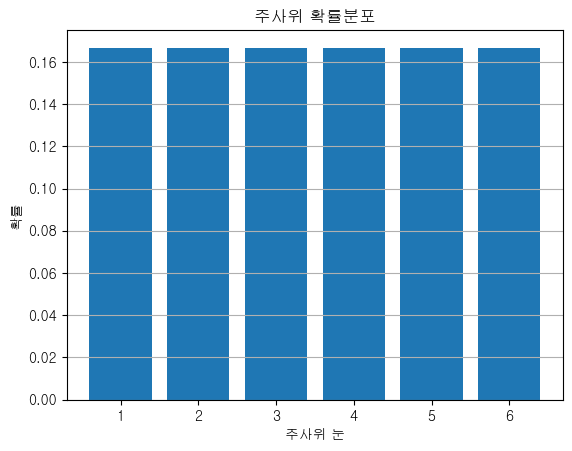

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 주사위 눈 (1~6)
x = np.arange(1, 7)
# 공정한 주사위의 확률분포: 모두 1/6
probs = [1/6] * 6  #6을 곱하는 이유는  6번 반복해서 리스트로 만든다는 의미 - 각 눈별로 확률이 동일하므로 모두 1/6로 설정

# 시각화
plt.bar(x, probs)
plt.xticks(x)
plt.xlabel("주사위 눈")
plt.ylabel("확률")
plt.title("주사위 확률분포")
plt.grid(axis='y')
plt.show()

동전 1회 던지기 결과: 앞면
1000번 던졌을 때 앞면 나온 횟수: 500
앞면 나올 확률 (이론값: 0.5, 실험값: 0.5000)


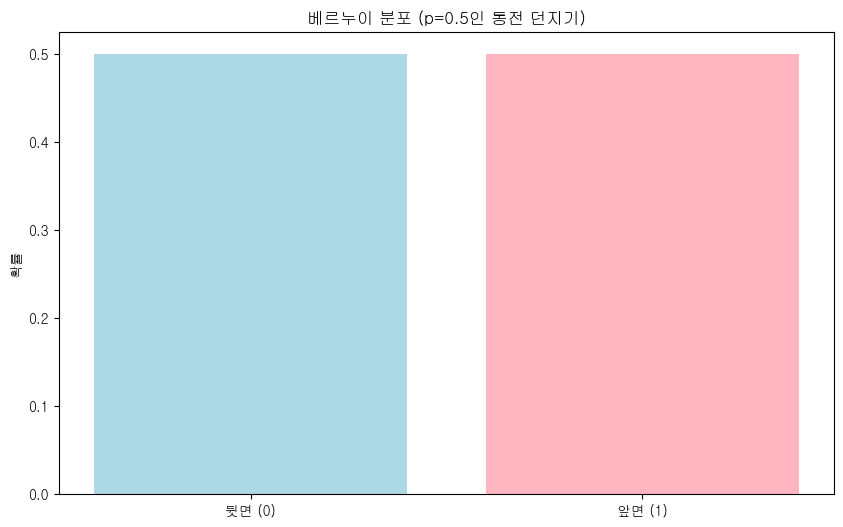

In [172]:
# 베르누이 분포 예시 - 동전 던지기
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# 베르누이 분포 파라미터 설정
p = 0.5  # 앞면이 나올 확률

# 베르누이 확률변수 생성
X = bernoulli(p) # x는 베르누이 확률모델

# 1회 시행 결과 시뮬레이션 (0: 뒷면, 1: 앞면)
result = X.rvs(size=1)
print(f"동전 1회 던지기 결과: {'앞면' if result[0] == 1 else '뒷면'}")

# 여러 번 시행 결과 시뮬레이션
n_trials = 1000
results = X.rvs(size=n_trials)

# 결과 분석
success_count = np.sum(results)
success_rate = success_count / n_trials

print(f"1000번 던졌을 때 앞면 나온 횟수: {success_count}")
print(f"앞면 나올 확률 (이론값: {p}, 실험값: {success_rate:.4f})")

# 시각화
plt.figure(figsize=(10, 6))
plt.bar([0, 1], [1-p, p], color=['lightblue', 'lightpink'])
plt.xticks([0, 1], ['뒷면 (0)', '앞면 (1)'])
plt.ylabel('확률')
plt.title('베르누이 분포 (p=0.5인 동전 던지기)')
plt.show()


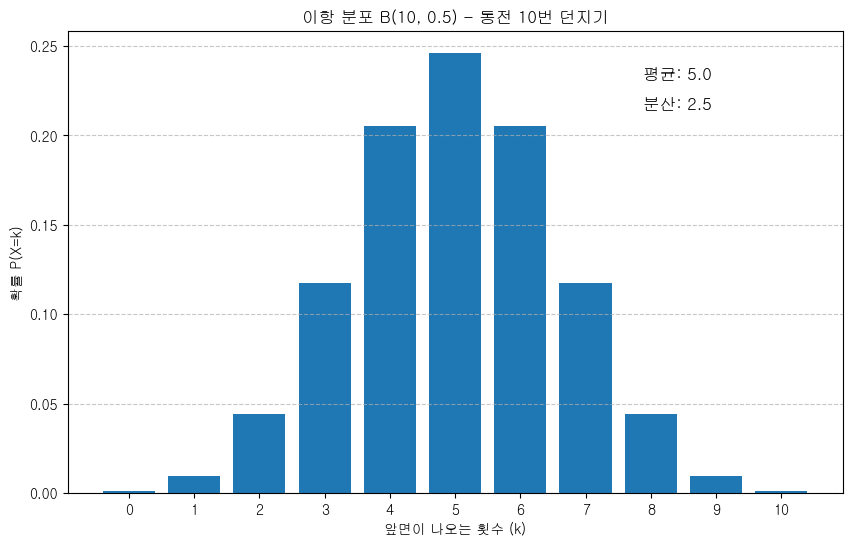

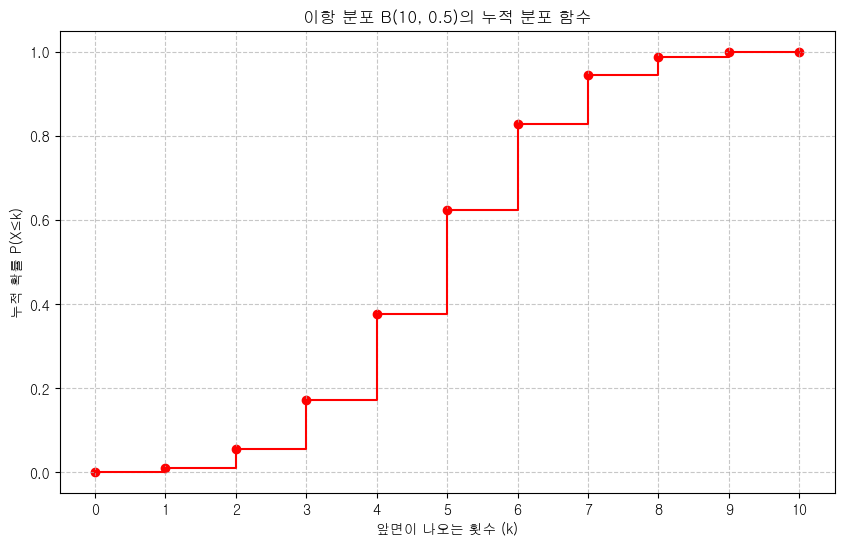

In [173]:
# 이항 분포 예시 - 동전 10번 던지기
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# 이항 분포 파라미터 설정
n = 10  # 시행 횟수
p = 0.5  # 성공 확률(동전 앞면이 나올 확률)

# 이항 확률변수 생성
X = binom(n, p)

# 가능한 모든 결과값(0부터 n까지)
k_values = np.arange(0, n+1)

# 각 결과값의 확률 계산
pmf_values = X.pmf(k_values)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values)
plt.xlabel('앞면이 나오는 횟수 (k)')
plt.ylabel('확률 P(X=k)')
plt.title(f'이항 분포 B({n}, {p}) - 동전 10번 던지기')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 평균과 분산 출력
mean = n * p
var = n * p * (1-p)
plt.figtext(0.7, 0.8, f'평균: {mean}', fontsize=12)
plt.figtext(0.7, 0.75, f'분산: {var}', fontsize=12)

plt.show()

# 누적 분포 함수(CDF) 계산 및 시각화
cdf_values = X.cdf(k_values)

plt.figure(figsize=(10, 6))
plt.step(k_values, cdf_values, where='post', color='red')
plt.scatter(k_values, cdf_values, color='red')
plt.xlabel('앞면이 나오는 횟수 (k)')
plt.ylabel('누적 확률 P(X≤k)')
plt.title(f'이항 분포 B({n}, {p})의 누적 분포 함수')
plt.xticks(k_values)
plt.grid(linestyle='--', alpha=0.7)
plt.show()


# 이항분포를 적용할 수 있는 사례

1. 시험합격률이 75%, 100명, 80명 이상 합격할 확률
2. 불량률 5%, 20개 샘플, 불량제품이 2개 이하일 확률